In [ ]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        "display_name": {"$regex": "train3.+"},
        
        # created at before may 7
        
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=100,
    # limit to 10:
    lazy=False
)

In [3]:
import itertools
runs_ = list(itertools.islice(runs, 100))

rows = []
for run in runs_:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
    })
df = pd.DataFrame(rows)
df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(ukr_rus_twitter|midterm|covid19_twitter)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.split('/').str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
d = {
    'trained_on_n_way': 'n_way',
    'trained_on_n_query': 'n_query',
    'trained_on_n_shots': 'n_shots',
    'trained_on_steps': 'steps',
}
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
dname2stats = df.set_index('display_name').loc[existing_trained_on_display_names][list(d.values())]
for col, stat in d.items():
    df[col] = df.trained_on_display_name.map(dname2stats[stat].to_dict())
df__ = df.copy()

df = df[df.state.ne('running')]
df['auc'] = df.test_roc_auc

In [46]:
df.to_csv('train3_apr_29.csv', index=False)

In [124]:
df = pd.read_csv('train3_apr_29.csv')

In [125]:
# df[df.test_roc_auc.notna()][['prefix', 'dataset', 'task_name', 'n_shots', 'auc']].to_csv()

In [126]:
df = df[df.test_roc_auc.notna()]
df[['prefix', 'dataset', 'task_name', 'n_shots', 'auc']]

,prefix,dataset,task_name,n_shots,auc
0,train3_exp3_covid_nm_to_ukr_rus_nm_to_election...,election2020,neighbor_matching,3,0.884957
2,train3_exp1_midterm_nm_to_covid_nm_to_ukr_rus_nm,ukr_rus_twitter,neighbor_matching,3,0.992306
4,train3_exp3_covid_nm_to_ukr_rus_nm_to_covid_po...,covid_political,neighbor_matching,3,0.916523
6,train3_exp2_midterm_nm_to_ukr_rus_nm_to_covid_nm,covid19_twitter,neighbor_matching,3,0.997812
8,train3_exp3_covid_nm_to_ukr_rus_nm_to_ukr_rus_...,ukr_rus_suspended,neighbor_matching,3,0.924127
9,train3_exp1_midterm_nm_to_covid_nm_to_election...,election2020,neighbor_matching,3,0.886265
10,train3_exp3_covid_nm_to_ukr_rus_nm_to_midterm_nm,midterm,neighbor_matching,3,0.967611
12,train3_exp2_midterm_nm_to_ukr_rus_nm_to_ukr_ru...,ukr_rus_suspended,neighbor_matching,3,0.936415
17,train3_exp1_midterm_nm_to_covid_nm_to_ukr_rus_...,ukr_rus_suspended,neighbor_matching,3,0.937227
19,train3_exp2_midterm_nm_to_ukr_rus_nm_to_electi...,election2020,neighbor_matching,3,0.885895


In [127]:
df[['train1_dataset', 'train1_task', 'train2_dataset', 'train2_task', 'train3_dataset', 'train3_task']] = \
    df.prefix.str.extract('train3_exp._(.+)_(nm|lp|pl)_to_(.+)_(nm|pl|lp)_to_(.+)_(nm|pl|lp)')

In [128]:
df[['train1_dataset', 'train1_task', 'train2_dataset', 'train2_task', 'train3_dataset', 'train3_task', 'n_shots', 'auc']].sort_values('train3_dataset')

,train1_dataset,train1_task,train2_dataset,train2_task,train3_dataset,train3_task,n_shots,auc
6,midterm,nm,ukr_rus,nm,covid,nm,3,0.997812
4,covid,nm,ukr_rus,nm,covid_political,nm,3,0.916523
22,midterm,nm,ukr_rus,nm,covid_political,nm,3,0.929782
23,midterm,nm,covid,nm,covid_political,nm,3,0.929723
0,covid,nm,ukr_rus,nm,election2020,nm,3,0.884957
9,midterm,nm,covid,nm,election2020,nm,3,0.886265
19,midterm,nm,ukr_rus,nm,election2020,nm,3,0.885895
10,covid,nm,ukr_rus,nm,midterm,nm,3,0.967611
2,midterm,nm,covid,nm,ukr_rus,nm,3,0.992306
8,covid,nm,ukr_rus,nm,ukr_rus_suspended,nm,3,0.924127


In [129]:
train1 = pd.read_csv('./train1/train1.csv')

In [130]:
df['train1_dataset'] = df.train1_dataset.replace({"covid": "covid19_twitter", "ukr_rus": "ukr_rus_twitter"})
df['train2_dataset'] = df.train2_dataset.replace({"covid": "covid19_twitter", "ukr_rus": "ukr_rus_twitter"})
df['train3_dataset'] = df.train3_dataset.replace({"covid": "covid19_twitter", "ukr_rus": "ukr_rus_twitter"})

In [131]:
df[['c1', 'c2', 'c3', 'n1', 'n2', 'n3']] = None

for i, row in df.iterrows():
    t1 = f'{row.train1_dataset}\+{row.train1_task}'
    t2 = f'{row.train2_dataset}\+{row.train2_task}'
    t3 = f'{row.train3_dataset}\+{row.train3_task}'
    p1 = f'{t1}\(\d+\)?\|{t1}\(3\)'
    p2 = f'{t2}\(\d+\)?\|{t2}\(3\)'
    p3 = f'{t3}\(\d+\)?\|{t3}\(3\)'
    c1 = train1[train1.seq.str.contains(p1)]
    a1 = c1.auc.values[0] if c1.shape[0] > 0 else np.nan
    n1 = c1.seq.values[0] if c1.shape[0] > 0 else np.nan
    c2 = train1[train1.seq.str.contains(p2)]
    a2 = c2.auc.values[0] if c2.shape[0] > 0 else np.nan
    n2 = c2.seq.values[0] if c2.shape[0] > 0 else np.nan
    c3 = train1[train1.seq.str.contains(p3)]
    a3 = c3.auc.values[0] if c3.shape[0] > 0 else np.nan
    n3 = c3.seq.values[0] if c3.shape[0] > 0 else np.nan
    df.loc[i, ['c1', 'c2', 'c3']] = [a1, a2, a3]
    df.loc[i, ['p1', 'p2', 'p3']] = [p1, p2, p3]
    df.loc[i, ['n1', 'n2', 'n3']] = [n1, n2, n3]

In [138]:
df['seq'] = (
    df.train1_dataset + '+' +
    df.train1_task + '>' +
    df.train2_dataset + '+' +
    df.train2_task + '>' +
    df.train3_dataset + '+' +
    df.train3_task
)

# df[['auc', 'seq', 'c1', 'p1', 'n1', 'c2', 'p2', 'n2', 'c3', 'p3', 'n3']]
# df..fillna(0).plot(y='seq', x='auc')
df[['seq', 'auc', 'c1', 'c2', 'c3']]

,seq,auc,c1,c2,c3
0,covid19_twitter+nm>ukr_rus_twitter+nm>election...,0.884957,0.997207,0.991099,NaN
2,midterm+nm>covid19_twitter+nm>ukr_rus_twitter+nm,0.992306,0.980944,0.997207,0.991099
4,covid19_twitter+nm>ukr_rus_twitter+nm>covid_po...,0.916523,0.997207,0.991099,NaN
6,midterm+nm>ukr_rus_twitter+nm>covid19_twitter+nm,0.997812,0.980944,0.991099,0.997207
8,covid19_twitter+nm>ukr_rus_twitter+nm>ukr_rus_...,0.924127,0.997207,0.991099,NaN
9,midterm+nm>covid19_twitter+nm>election2020+nm,0.886265,0.980944,0.997207,NaN
10,covid19_twitter+nm>ukr_rus_twitter+nm>midterm+nm,0.967611,0.997207,0.991099,0.980944
12,midterm+nm>ukr_rus_twitter+nm>ukr_rus_suspende...,0.936415,0.980944,0.991099,NaN
17,midterm+nm>covid19_twitter+nm>ukr_rus_suspende...,0.937227,0.980944,0.997207,NaN
19,midterm+nm>ukr_rus_twitter+nm>election2020+nm,0.885895,0.980944,0.991099,NaN


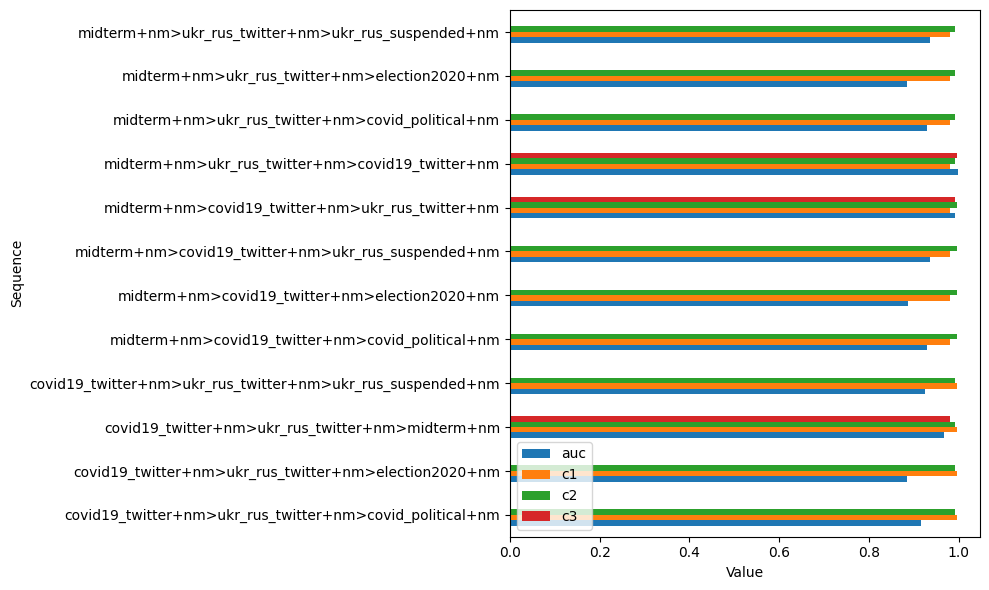

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df.copy()

# optional: keep only top N by auc (otherwise unreadable)
pdf = pdf.sort_values("auc", ascending=False).head(15)

# reshape to long format
long = df.melt(
    id_vars=["seq"],
    value_vars=['auc', "c1", "c2", "c3"],
    var_name="metric",
    value_name="value"
).dropna()

# pivot for grouped bars
pivot = long.pivot(index="seq", columns="metric", values="value")

# plot
pivot.plot(kind="barh", figsize=(10, 6))

plt.xlabel("Value")
plt.ylabel("Sequence")
plt.tight_layout()
plt.legend(loc='lower left')
plt.show()

# Full matrix

In [3]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "train3.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=100,
    # limit to 10:
    lazy=False
)


In [ ]:
import pandas as pd

task_map = {
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
}
    
def to_pandas(runs):
    rows = []
    for r, run in enumerate(runs):
        attrs = getattr(run, "_attrs", {}) or {}
        params = ((attrs.get("config") or {}).get("params") or {})
        summary = attrs.get("summaryMetrics") or {}

        rows.append({
            "run_id": attrs.get("name"),
            "display_name": attrs.get("displayName"),
            "state": attrs.get("state"),
            "dataset": params.get("dataset"),
            "task_name": params.get("task_name"),
            "prefix": params.get("prefix"),
            "pretrained_model_run": params.get("pretrained_model_run"),
            "n_shots": params.get("n_shots"),
            "n_way": params.get("n_way"),
            "n_query": params.get("n_query"),
            "zero_shot": params.get("zero_shot"),
            "test_accuracy": summary.get("test_accuracy"),
            "train_accuracy": summary.get("train_accuracy"),
            "test_f1": summary.get("test_f1"),
            "test_roc_auc": summary.get("test_roc_auc"),
            "graph": str(params.get("root", 'no_root')) + "/" + str(params.get("graph_filename", 'no_filename')),
            "eval_only": params.get("eval_only"),
            "created_at": attrs.get("createdAt"),
            'train_steps': summary.get('_step'),
            'test_len_cap': params.get('test_len_cap'),
            'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
            'tags': attrs.get("tags", []),
            'run': runs[r]
        })
    df = pd.DataFrame(rows)
    
    df["eval1_task"] = df["task_name"].map(task_map)
    df["task_name"] = df["task_name"].map(task_map)
    df['created_at'] = pd.to_datetime(df['created_at'])
    df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
    df['eval1_dataset'] = df['dataset']
    df['task_name'] = df['task_name'].str.replace({'classification': 'pl', 'neighbor_matching': 'nm', 'temporal_link_prediction': 'lp'})
    pat = r'(?:state|/scratch1/singhama/data/experiments)/([^/]+)/.+'
    df['trained_on_display_name'] = df.pretrained_model_run.str.extract(pat)[0]
    df = df[~df.prefix.str.contains('pretrain_midterm_nm_test') & ~df.trained_on_display_name.str.contains('pretrain_midterm_nm_test')]
    df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
    
    df = df[~df.pretrained_model_run.str.contains('state/train1_midterm_lp_03_05_2026_14_49_53/checkpoint/state_dict_20000.ckpt', regex=False)]
    df = df[~df.pretrained_model_run.str.contains('train1_midterm_nm_24_03_2026_12_15_40', regex=False)]
    df = df[~df.pretrained_model_run.str.contains('train1_midterm_nm_aug_03_05_2026_20_36_07', regex=False)]
    
    df = df[df.state.ne('running')]
    df = df[df.created_at.gt("03-25-2026")]
    df = df[df.n_shots.notna()]

    df["train_tuples"] = None  # or use pd.Series(dtype=object)
    df["run_list"] = None  # or use pd.Series(dtype=object)
    
    df['shots'] = pd.to_numeric(df['n_shots']).fillna(-1).astype(int)

    for i, row in list(df.iterrows()):
        train_list = []
        run_list = []
        row_ = row.copy()
        # print(row_.display_name)

        while pd.notna(row_.trained_on_display_name):
            # print("->", row_.trained_on_display_name)
            matches = df[df.display_name.eq(row_.trained_on_display_name)]
            if len(matches) != 1:
                print('warn:', row_.trained_on_display_name, 'has', len(matches), 'matches')
                break
            row_ = matches.iloc[0]
            train_list.append((row_["dataset"], row_["task_name"], row_.get('shots', -1)))
            run_list.append(row_.run_id)

        # print('\t', train_list)
        df.at[i, "train_tuples"] = train_list
        df.at[i, "run_list"] = run_list

        
    df['auc'] = df.test_roc_auc

    eval_only = df.eval_only.ne(False)
    df.loc[eval_only, 'eval_dataset'] = df.dataset
    df.loc[eval_only, 'eval_task'] = df.task_name
    df.loc[eval_only, 'eval_id'] = df.loc[eval_only].eval_dataset + "+" + df.loc[eval_only].eval_task + "(" + df.loc[eval_only].shots.astype(str) + ")"
    df.loc[eval_only, 'run_idx'] = df.loc[eval_only].run_list.apply('>'.join).replace('', 'nan') + "|" + df.loc[eval_only].eval_id
    
    df['train_id'] = df.train_tuples.apply(lambda x: [f'{d}+{t}({s})' for (d,t,s) in x]).apply('>'.join).replace({'':np.nan})
    apat = f"/scratch1/singhama/data/experiments/([^/]+)/"
    a = df.pretrained_model_run.str.contains(apat)
    df.loc[a, 'run_list'] = df.loc[a, 'pretrained_model_run'].str.findall(apat).str[0]
    ds_map = {
        "covid": 'covid19_twitter',
        'ukr_rus': 'ukr_rus_twitter'
    }
    df.loc[a, 'train_id'] = df.loc[a, 'run_list'].str.replace(ds_map).str.findall("train2_(.+)_(nm|lp|pl)_to_(.+)_(lp|pl|nm)").str[0].apply(lambda x: f"{x[0]}+{x[1]}()>{x[2]}+{x[3]}()")
    df.loc[eval_only, 'eval_dataset'] = df.loc[eval_only, 'dataset']
    df.loc[eval_only, 'eval_task'] = df.loc[eval_only, 'task_name']
    df['seq'] = df.train_id.fillna('nan') + "|" + df.eval_id.fillna('nan')
    
    graphs = ["/scratch1/eibl/data/covid_political/graphs/retweet_graph.pt",
    "/scratch1/eibl/data/election2020/graphs/retweet_graph.pt",
    "/scratch1/eibl/data/ukr_rus_suspended/graphs/retweet_graph.pt",
    "/scratch1/eibl/data/covid19_twitter/graphs/retweet_graph_1p5m_hf03_labeled.pt",
    "/scratch1/eibl/data/ukr_rus_twitter/graphs/retweet_graph_1p5m_hf03_political_labels.pt",
    "/scratch1/eibl/data/midterm/graphs/retweet_graph_1p5m.pt",]
    
    df = df[df.graph.isin(graphs)]

    return df

try: 
    df = pd.read_csv('train3_raw.csv')
except:
    df = to_pandas(runs)
    df_ = df.copy()

    df.to_csv('train3_raw.csv', index=False)

In [412]:
edf = df[df.eval_only]
edf['auc_adj'] = edf.auc.apply(lambda x: max(x, 1-x))
edf['auc_adj_round'] = edf.auc_adj.round(2)

In [413]:
edf.seq

12      covid_political+pl(3)|election2020+pl(3)
13      covid_political+pl(3)|election2020+nm(3)
14      covid_political+pl(3)|election2020+pl(0)
15      covid_political+pl(3)|election2020+nm(0)
16      covid_political+nm(3)|election2020+pl(3)
                          ...                   
1618         ukr_rus_twitter+nm(1)|midterm+pl(0)
1619         ukr_rus_twitter+nm(1)|midterm+lp(0)
1620         covid19_twitter+nm(1)|midterm+lp(0)
1621         covid19_twitter+nm(1)|midterm+nm(0)
1622         ukr_rus_twitter+nm(1)|midterm+nm(0)
Name: seq, Length: 1490, dtype: str

In [414]:
# runs are unique on
# ['train1_dataset', 'train1_task', '', 'train2_dataset', 'train2_task']

# evals are unique on
unique = ['eval_dataset', 'train_id','seq', 'eval_task', 'n_way', 'n_shots', 'n_query', 'auc_adj_round']
edf = edf.drop_duplicates(subset=unique)
edf[edf.duplicated(subset=['seq', 'n_way', 'n_shots', 'n_query'], keep=False)].sort_values(unique)[['seq',  'n_way', 'n_shots', 'n_query', 'auc_adj_round', 'pretrained_model_run', 'auc']]

,seq,n_way,n_shots,n_query,auc_adj_round,pretrained_model_run,auc
166,covid19_twitter+lp(1)|covid19_twitter+pl(0),2.0,0.0,12.0,0.54,state/train1_covid19_twitter_lp_1p5m_13_04_202...,0.459834
1503,covid19_twitter+lp(1)|covid19_twitter+pl(0),2.0,0.0,12.0,0.56,state/train1_covid19_twitter_lp_1p5m_13_04_202...,0.444207
1587,covid19_twitter+nm(1)|covid19_twitter+pl(0),2.0,0.0,12.0,0.53,state/train1_covid19_twitter_nm_1p5m_13_04_202...,0.472362
183,covid19_twitter+nm(1)|covid19_twitter+pl(0),2.0,0.0,12.0,0.58,state/train1_covid19_twitter_nm_1p5m_13_04_202...,0.422722
143,covid19_twitter+pl(4)|covid19_twitter+pl(3),2.0,3.0,12.0,0.83,state/train1_covid19_twitter_pl_1p5m_13_04_202...,0.165445
...,...,...,...,...,...,...,...
200,ukr_rus_twitter+nm(1)|ukr_rus_twitter+pl(0),2.0,0.0,12.0,0.69,state/train1_ukr_rus_twitter_nm_1p5m_13_04_202...,0.308212
145,ukr_rus_twitter+pl(4)|ukr_rus_twitter+pl(0),2.0,0.0,12.0,0.92,state/train1_ukr_rus_twitter_pl_1p5m_13_04_202...,0.083698
1437,ukr_rus_twitter+pl(4)|ukr_rus_twitter+pl(0),2.0,0.0,12.0,0.94,state/train1_ukr_rus_twitter_pl_1p5m_13_04_202...,0.935226
135,ukr_rus_twitter+pl(4)|ukr_rus_twitter+pl(3),2.0,3.0,12.0,0.52,state/train1_ukr_rus_twitter_pl_1p5m_13_04_202...,0.522586


In [415]:
edf = edf.groupby(['pretrained_model_run', 'seq']).apply(lambda x: x.sort_values('created_at', ascending=False).iloc[0]).reset_index()
edf.groupby('seq').pretrained_model_run.unique().sort_values(key=lambda x: x.str.len()).iloc[-1]

<ArrowStringArray>
['state/train1_ukr_rus_twitter_pl_1p5m_13_04_2026_11_30_52/checkpoint/state_dict_22000.ckpt']
Length: 1, dtype: str

In [416]:
edf.to_csv('runs_cleaned_may7.csv')

In [417]:
edf.shots.value_counts()

shots
0     300
3     300
1     165
10    165
Name: count, dtype: int64

In [418]:
# edf.loc[edf.train_id.str.contains('\>'), 'exp_name'] = 
edf[edf.shots.isin([3])][['train_id', 'eval_id', 'auc']]

,train_id,eval_id,auc
1,midterm+nm()>ukr_rus_twitter+nm(),covid19_twitter+lp(3),0.820548
3,midterm+nm()>ukr_rus_twitter+nm(),covid19_twitter+nm(3),0.985326
5,midterm+nm()>ukr_rus_twitter+nm(),covid19_twitter+pl(3),0.533996
7,midterm+nm()>ukr_rus_twitter+nm(),covid_political+nm(3),0.720593
9,midterm+nm()>ukr_rus_twitter+nm(),covid_political+pl(3),0.667246
...,...,...,...
913,ukr_rus_twitter+pl(4),ukr_rus_suspended+nm(3),0.512275
917,ukr_rus_twitter+pl(4),ukr_rus_suspended+pl(3),0.497142
921,ukr_rus_twitter+pl(4),ukr_rus_twitter+lp(3),0.531040
925,ukr_rus_twitter+pl(4),ukr_rus_twitter+nm(3),0.731880


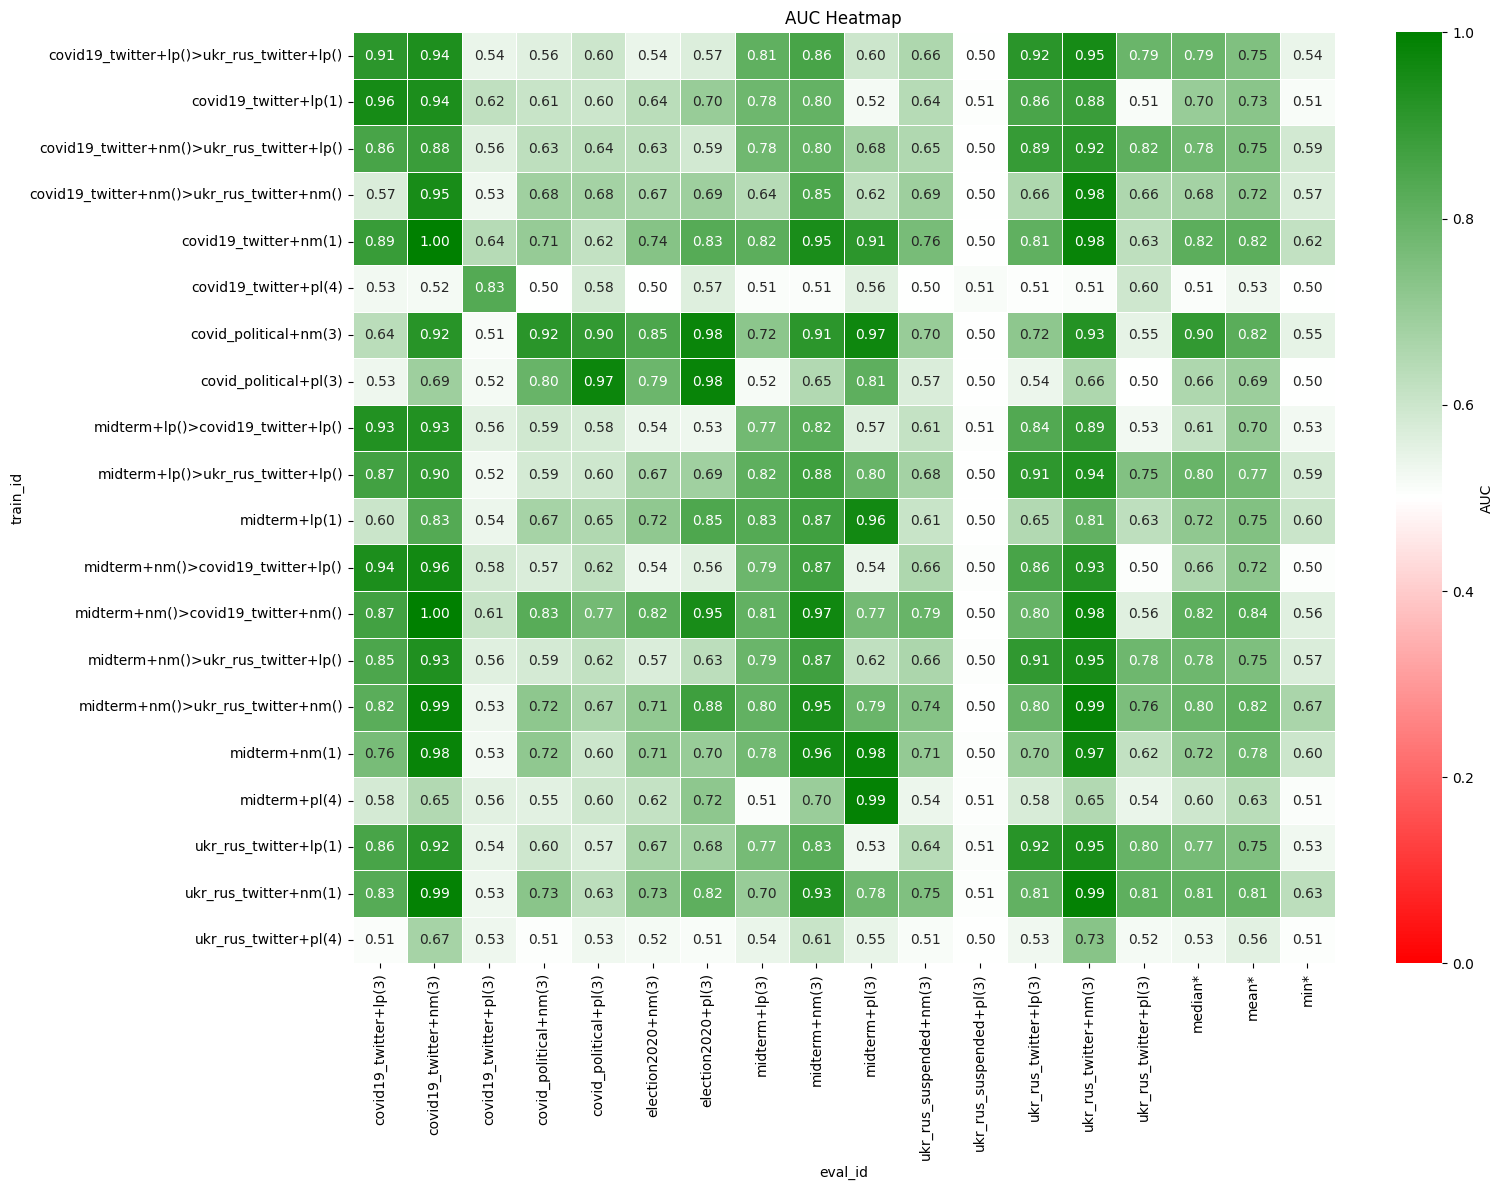

In [437]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# df has columns: train_id, eval_id, auc

heatmap_df = edf[edf.shots.eq(3)].pivot(index="train_id", columns="eval_id", values="auc_adj")
i = ~edf.eval_id.str.contains('ukr_rus_suspended\+pl\(3\)|covid19_twitter\+pl\(3\)')
heatmap_df_ = edf[edf.shots.eq(3) & i].pivot(index="train_id", columns="eval_id", values="auc_adj")
heatmap_df["median*"] = heatmap_df_.median(axis=1)
heatmap_df["mean*"] = heatmap_df_.mean(axis=1)
heatmap_df["min*"] = heatmap_df_.min(axis=1)

# 0 -> red, 0.5 -> white, 1 -> green
cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    [(0.0, "red"), (0.5, "white"), (1.0, "green")]
)

norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

plt.figure(figsize=(16, 12))
sns.heatmap(
    heatmap_df,
    cmap=cmap,
    norm=norm,
    annot=True,          # add cell values
    fmt=".2f",           # use ".3f" if you want more precision
    linewidths=0.5,
    cbar_kws={"label": "AUC"}
)

plt.xlabel("eval_id")
plt.ylabel("train_id")
plt.title("AUC Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

mean scores on NM across all graphs
mean scores on LP across all graphs
mean scores on PL across all graphs


/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_3002/386196025.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  nm = h.mean(1).sort_values()
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_3002/386196025.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  lp = h.mean(1).sort_values()
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_3002/386196025.py:20: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  pl = h.mean(1).sort_values()


<Axes: ylabel='train_id'>

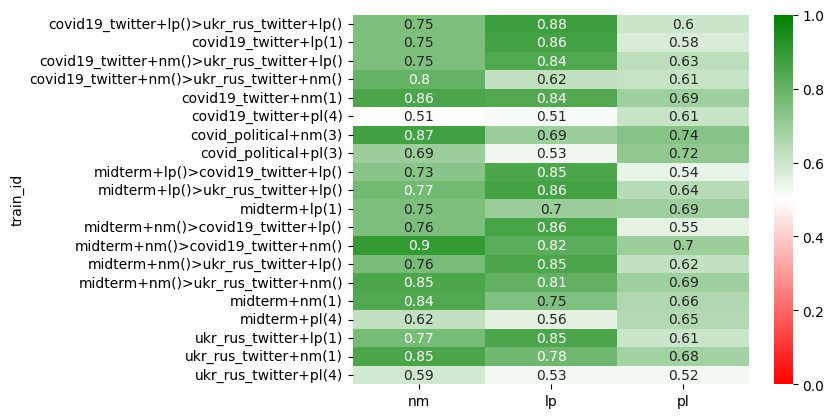

In [659]:
h = heatmap_df.copy()

# h = h[h.index.str.contains('nm')]
h = h.T[h.T.index.str.contains('nm')].T
print('mean scores on NM across all graphs')
nm = h.mean(1).sort_values()

h = heatmap_df.copy()

# h = h[h.index.str.contains('nm')]
h = h.T[h.T.index.str.contains('lp')].T
print('mean scores on LP across all graphs')
lp = h.mean(1).sort_values()

h = heatmap_df.copy()

# h = h[h.index.str.contains('nm')]
h = h.T[h.T.index.str.contains('pl')].T
print('mean scores on PL across all graphs')
pl = h.mean(1).sort_values()

comp = pd.DataFrame({'nm': nm, 'lp': lp, 'pl': pl})

sns.heatmap(comp, vmin=0, vmax=1, 
                cmap=cmap,
                annot=True,
                )

eval_id,covid19_twitter+nm(3),covid_political+nm(3),election2020+nm(3),midterm+nm(3),ukr_rus_suspended+nm(3),ukr_rus_twitter+nm(3)
train_id,,,,,,
covid19_twitter,0.941674,0.607643,0.635694,0.803856,0.643615,0.883914
covid19_twitter,0.997386,0.706356,0.735241,0.946803,0.762650,0.982303
covid19_twitter,0.520870,0.502246,0.500006,0.507928,0.500661,0.510203
covid_political,0.921131,0.917625,0.848737,0.911228,0.700398,0.926397
covid_political,0.691224,0.796258,0.788752,0.648560,0.573915,0.657907
midterm,0.832471,0.673774,0.715910,0.873791,0.606585,0.807494
midterm,0.983520,0.717499,0.708871,0.964037,0.708341,0.972005
midterm,0.648994,0.554734,0.616033,0.697150,0.538500,0.650987
ukr_rus_twitter,0.917416,0.595018,0.668103,0.827372,0.639191,0.947754


<Axes: xlabel='eval_id', ylabel='train_id'>

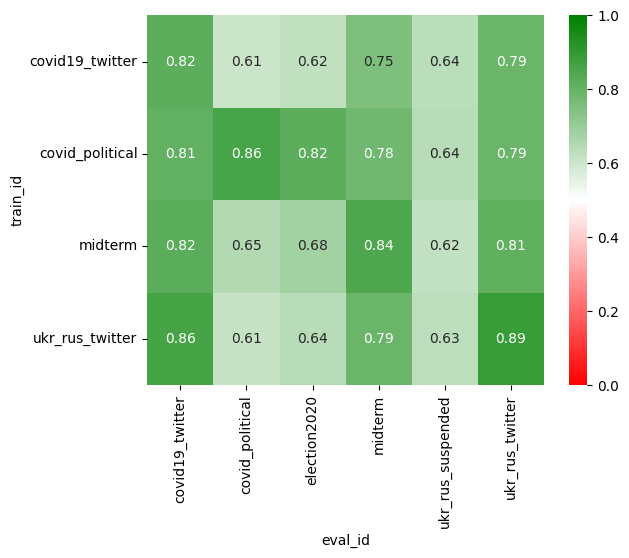

In [653]:
h = heatmap_df.copy()

h = h[~h.index.str.contains('\>')]
h.index = h.index.str.split('\+').str[0]
h = h.drop(columns=[c for c in h.columns if c.endswith('*') or 'nm' not in c])
display(h)
h.columns = h.columns.str.split('\+').str[0]
h = h.groupby(level=0).mean()
h = h.T.groupby(level=0).mean().T
sns.heatmap(h, vmin=0, vmax=1, 
                cmap=cmap,
                annot=True,
                )

eval_id,covid19_twitter+pl(3),covid_political+pl(3),election2020+pl(3),midterm+pl(3),ukr_rus_suspended+pl(3),ukr_rus_twitter+pl(3)
train_id,,,,,,
covid19_twitter,0.624822,0.601313,0.701785,0.521762,0.505619,0.512312
covid19_twitter,0.642084,0.620169,0.828245,0.910431,0.502170,0.625068
covid19_twitter,0.834555,0.578525,0.565584,0.560077,0.514714,0.596572
covid_political,0.511847,0.899614,0.977745,0.972475,0.503146,0.549120
covid_political,0.520553,0.973475,0.983138,0.813034,0.503397,0.503112
midterm,0.536136,0.653709,0.847246,0.961389,0.501554,0.628116
midterm,0.526010,0.601280,0.700526,0.982453,0.504998,0.618678
midterm,0.555313,0.597423,0.722627,0.989565,0.505018,0.541966
ukr_rus_twitter,0.543871,0.570275,0.681322,0.528629,0.509654,0.796890


<Axes: xlabel='eval_id', ylabel='train_id'>

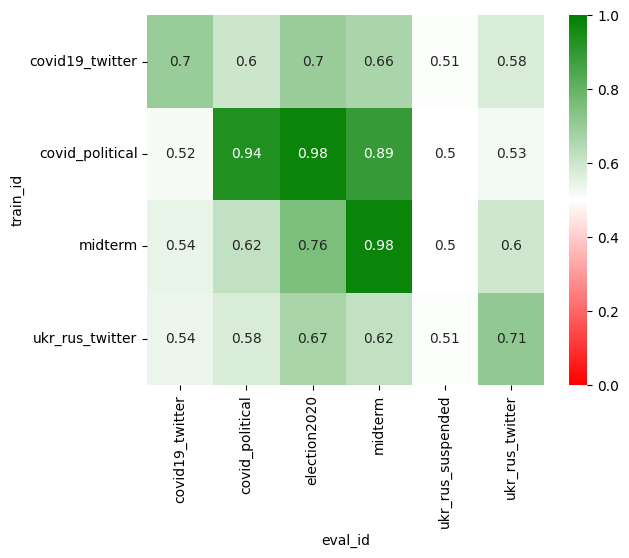

In [654]:
h = heatmap_df.copy()

h = h[~h.index.str.contains('\>')]
h.index = h.index.str.split('\+').str[0]
h = h.drop(columns=[c for c in h.columns if c.endswith('*') or 'pl' not in c])
display(h)
h.columns = h.columns.str.split('\+').str[0]
h = h.groupby(level=0).mean()
h = h.T.groupby(level=0).mean().T
sns.heatmap(h, vmin=0, vmax=1, 
                cmap=cmap,
                annot=True,
                )

eval_id,covid19_twitter+lp(3),midterm+lp(3),ukr_rus_twitter+lp(3)
train_id,,,
covid19_twitter,0.955070,0.783520,0.855443
covid19_twitter,0.887047,0.818809,0.810833
covid19_twitter,0.527322,0.510952,0.505070
covid_political,0.636717,0.724493,0.720956
covid_political,0.532315,0.515791,0.538712
midterm,0.604596,0.833926,0.650669
midterm,0.764309,0.775921,0.698459
midterm,0.584717,0.508332,0.576442
ukr_rus_twitter,0.857332,0.766250,0.921011


<Axes: xlabel='eval_id', ylabel='train_id'>

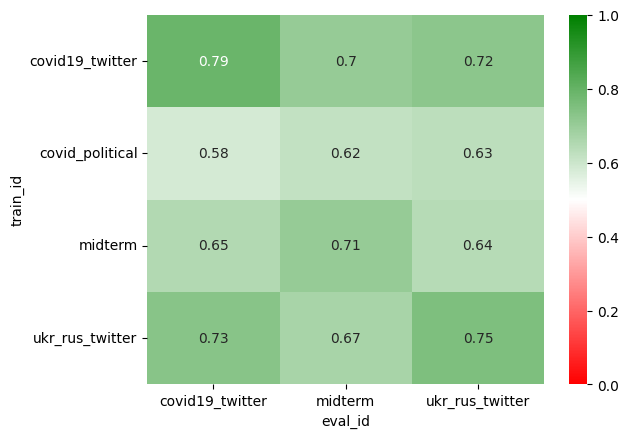

In [655]:
h = heatmap_df.copy()

h = h[~h.index.str.contains('\>')]
h.index = h.index.str.split('\+').str[0]
h = h.drop(columns=[c for c in h.columns if c.endswith('*') or 'lp' not in c])
display(h)
h.columns = h.columns.str.split('\+').str[0]
h = h.groupby(level=0).mean()
h = h.T.groupby(level=0).mean().T
sns.heatmap(h, vmin=0, vmax=1, 
                cmap=cmap,
                annot=True,
                )